# Explainable AI (XAI) Techniques in CNN Models
### Assignment: Implementing Explainable AI on MNIST using CNN

**Student Name:** Srushti Ravindra Kapase

**PRN:** 202301040025

**Subject:** Machine Learning / Deep Learning  


---
## Step 0: Install Required Libraries

In [1]:
# Run this cell once to install dependencies
!pip install tensorflow shap lime matplotlib seaborn scikit-learn numpy pandas -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## Part 1: Dataset Selection and Preprocessing

### Dataset: MNIST (Modified National Institute of Standards and Technology)

The MNIST dataset is one of the most well-known datasets in machine learning. It contains:
- **70,000 grayscale images** of handwritten digits (0–9)
- **Image size:** 28×28 pixels
- **Classes:** 10 (digits 0 through 9)
- **Training set:** 60,000 images | **Test set:** 10,000 images

I chose MNIST because it is simple enough to train quickly but complex enough to demonstrate XAI techniques meaningfully.

In [2]:
# ─── Import All Libraries ───────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import shap

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print("All libraries imported successfully!")

TensorFlow version: 2.20.0
NumPy version: 2.2.6
All libraries imported successfully!


In [3]:
# ─── Load Dataset ───────────────────────────────────────────────────────────
(X_train_raw, y_train), (X_test_raw, y_test) = mnist.load_data()

print("=== Dataset Information ===")
print(f"Training samples   : {X_train_raw.shape[0]}")
print(f"Test samples       : {X_test_raw.shape[0]}")
print(f"Image shape        : {X_train_raw.shape[1:]}")
print(f"Pixel value range  : {X_train_raw.min()} to {X_train_raw.max()}")
print(f"Number of classes  : {len(np.unique(y_train))}")
print(f"Classes            : {np.unique(y_train)}")

=== Dataset Information ===
Training samples   : 60000
Test samples       : 10000
Image shape        : (28, 28)
Pixel value range  : 0 to 255
Number of classes  : 10
Classes            : [0 1 2 3 4 5 6 7 8 9]


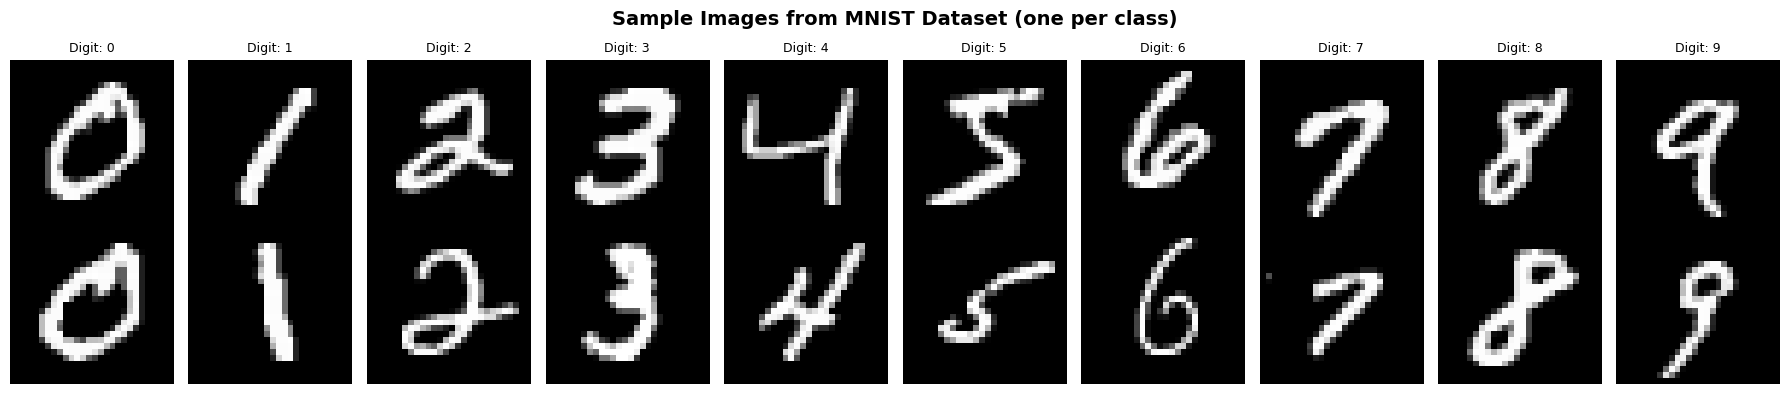

Figure saved as 'sample_images.png'


In [4]:
# ─── Visualize Sample Images ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle('Sample Images from MNIST Dataset (one per class)', fontsize=14, fontweight='bold')

for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    axes[0, digit].imshow(X_train_raw[idx], cmap='gray')
    axes[0, digit].set_title(f'Digit: {digit}', fontsize=9)
    axes[0, digit].axis('off')
    
    idx2 = np.where(y_train == digit)[0][1]
    axes[1, digit].imshow(X_train_raw[idx2], cmap='gray')
    axes[1, digit].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as 'sample_images.png'")

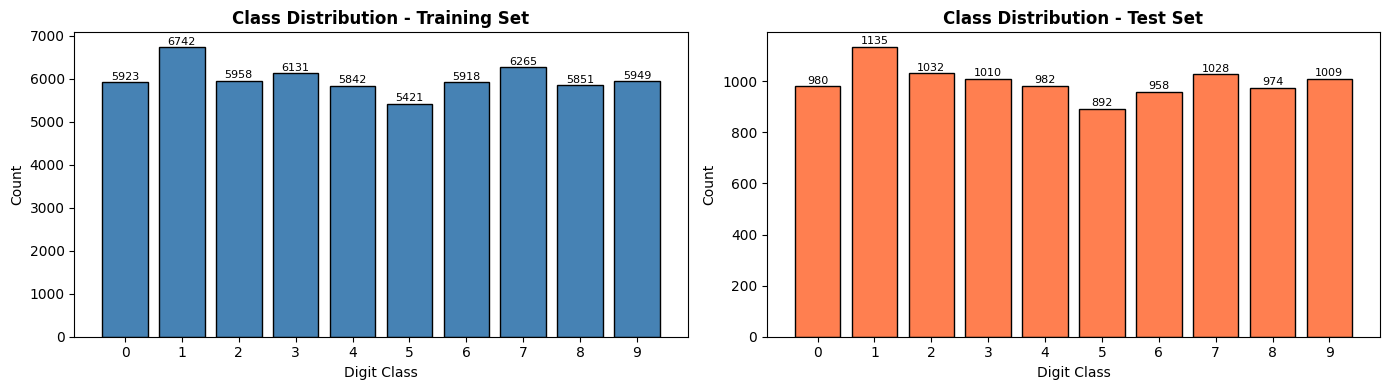

The dataset is well-balanced across all 10 digit classes.


In [5]:
# ─── Check Class Distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_test, counts_test = np.unique(y_test, return_counts=True)

axes[0].bar(unique_train, counts_train, color='steelblue', edgecolor='black')
axes[0].set_title('Class Distribution - Training Set', fontweight='bold')
axes[0].set_xlabel('Digit Class')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(10))
for i, v in enumerate(counts_train):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=8)

axes[1].bar(unique_test, counts_test, color='coral', edgecolor='black')
axes[1].set_title('Class Distribution - Test Set', fontweight='bold')
axes[1].set_xlabel('Digit Class')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(10))
for i, v in enumerate(counts_test):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("The dataset is well-balanced across all 10 digit classes.")

In [6]:
# ─── Preprocessing ──────────────────────────────────────────────────────────
# Step 1: Reshape images to add channel dimension (required by CNN)
X_train = X_train_raw.reshape(-1, 28, 28, 1)
X_test  = X_test_raw.reshape(-1, 28, 28, 1)

# Step 2: Normalize pixel values from [0, 255] to [0.0, 1.0]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

# Step 3: One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test,  num_classes=10)

print("=== After Preprocessing ===")
print(f"X_train shape : {X_train.shape}  | Pixel range: [{X_train.min():.2f}, {X_train.max():.2f}]")
print(f"X_test shape  : {X_test.shape}   | Pixel range: [{X_test.min():.2f}, {X_test.max():.2f}]")
print(f"y_train shape : {y_train_cat.shape} (one-hot encoded)")
print(f"y_test shape  : {y_test_cat.shape}  (one-hot encoded)")
print("\nPreprocessing complete!")

=== After Preprocessing ===
X_train shape : (60000, 28, 28, 1)  | Pixel range: [0.00, 1.00]
X_test shape  : (10000, 28, 28, 1)   | Pixel range: [0.00, 1.00]
y_train shape : (60000, 10) (one-hot encoded)
y_test shape  : (10000, 10)  (one-hot encoded)

Preprocessing complete!


---
## Part 2: CNN Model Implementation

### Model Architecture
I designed a Convolutional Neural Network with the following architecture:

| Layer | Type | Output Shape | Parameters |
|-------|------|-------------|------------|
| 1 | Conv2D (32 filters, 3×3, ReLU) | 26×26×32 | 320 |
| 2 | BatchNormalization | 26×26×32 | 128 |
| 3 | MaxPooling2D (2×2) | 13×13×32 | 0 |
| 4 | Conv2D (64 filters, 3×3, ReLU) | 11×11×64 | 18,496 |
| 5 | BatchNormalization | 11×11×64 | 256 |
| 6 | MaxPooling2D (2×2) | 5×5×64 | 0 |
| 7 | Conv2D (64 filters, 3×3, ReLU) | 3×3×64 | 36,928 |
| 8 | Flatten | 576 | 0 |
| 9 | Dense (128, ReLU) | 128 | 73,856 |
| 10 | Dropout (0.5) | 128 | 0 |
| 11 | Dense (10, Softmax) | 10 | 1,290 |

In [7]:
# ─── Build CNN Model ─────────────────────────────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)

model = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), padding='valid', name='conv2d_1'),
    BatchNormalization(name='bn_1'),
    MaxPooling2D((2, 2), name='pool_1'),

    # Block 2
    Conv2D(64, (3, 3), activation='relu', padding='valid', name='conv2d_2'),
    BatchNormalization(name='bn_2'),
    MaxPooling2D((2, 2), name='pool_2'),

    # Block 3
    Conv2D(64, (3, 3), activation='relu', padding='valid', name='conv2d_3'),

    # Classifier Head
    Flatten(name='flatten'),
    Dense(128, activation='relu', name='dense_1'),
    Dropout(0.5, name='dropout'),
    Dense(10, activation='softmax', name='output')
], name='MNIST_CNN')

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "MNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 26, 26, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 11, 11, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,274 (512.79 KB)

 Trainable params: 131,082 (512.04 KB)

 Non-trainable params: 192 (768.00 B)

In [8]:
# ─── Train the Model ─────────────────────────────────────────────────────────
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("\nModel training complete!")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9426 - loss: 0.1961 - val_accuracy: 0.9855 - val_loss: 0.0491
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9804 - loss: 0.0667 - val_accuracy: 0.9877 - val_loss: 0.0439
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9851 - loss: 0.0499 - val_accuracy: 0.9873 - val_loss: 0.0511
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.9884 - loss: 0.0390 - val_accuracy: 0.9918 - val_loss: 0.0314
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.9900 - loss: 0.0334 - val_accuracy: 0.9918 - val_loss: 0.0332
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9910 - loss: 0.0287 - val_accuracy: 0.9913 - val_loss: 0.0402
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.9919 - loss: 0.0270 - val_accuracy: 0.9910 - val_loss: 0.0385

Model training complete!


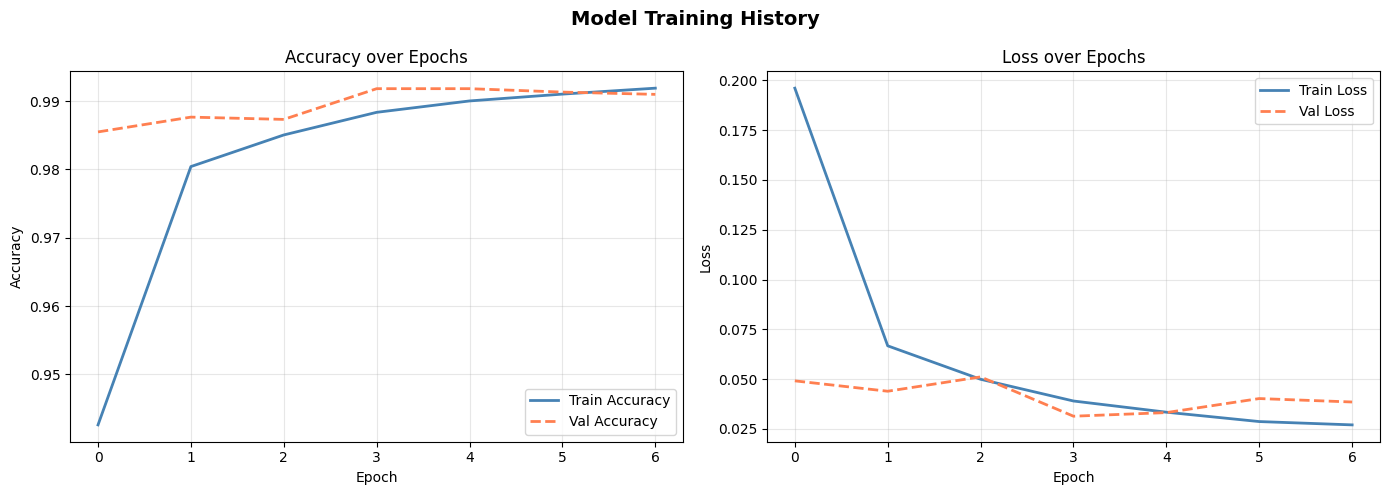

In [9]:
# ─── Plot Training History ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Training History', fontsize=14, fontweight='bold')

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='steelblue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='coral', linewidth=2, linestyle='--')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', color='steelblue', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', color='coral', linewidth=2, linestyle='--')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ─── Evaluate the Model ───────────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print("=" * 55)
print(f"  Test Accuracy : {test_acc * 100:.2f}%")
print(f"  Test Loss     : {test_loss:.4f}")
print("=" * 55)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=[f'Digit {i}' for i in range(10)]))

  Test Accuracy : 98.82%
  Test Loss     : 0.0409

=== Classification Report ===
              precision    recall  f1-score   support

     Digit 0       0.99      0.99      0.99       980
     Digit 1       0.98      1.00      0.99      1135
     Digit 2       1.00      0.98      0.99      1032
     Digit 3       0.99      0.99      0.99      1010
     Digit 4       0.99      0.97      0.98       982
     Digit 5       0.98      0.99      0.99       892
     Digit 6       0.99      0.99      0.99       958
     Digit 7       0.98      0.99      0.99      1028
     Digit 8       0.99      0.99      0.99       974
     Digit 9       0.98      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



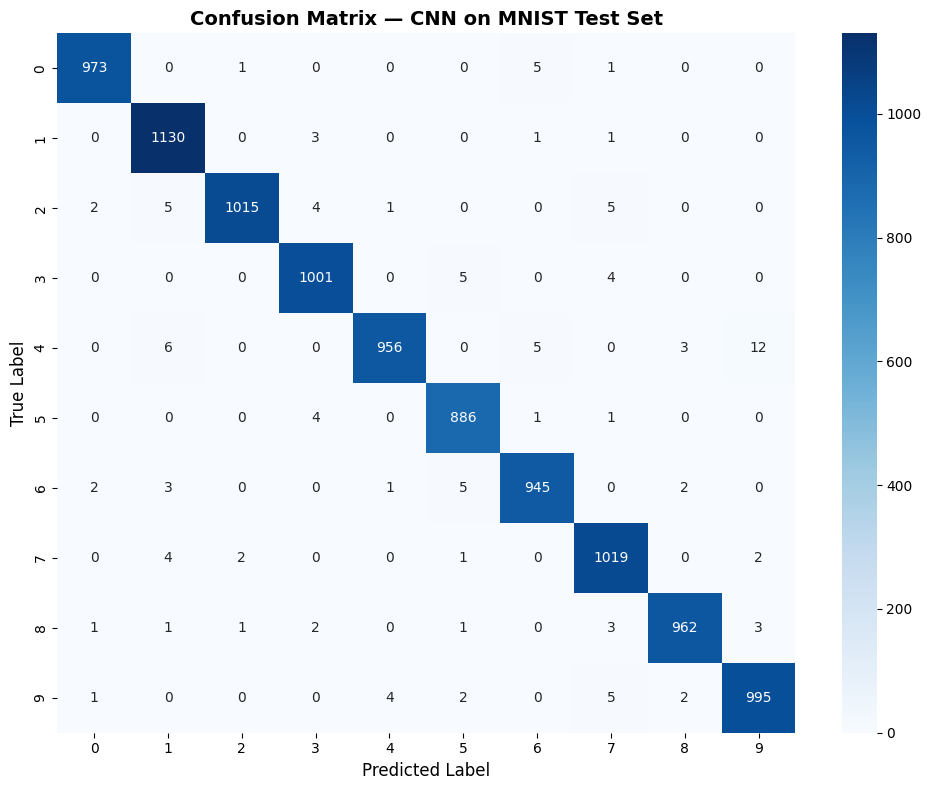

Observation: The diagonal entries are very high, indicating the model is classifying most digits correctly.
Most confusions occur between visually similar digits like 4↔9, 3↔5, 7↔2.


In [11]:
# ─── Confusion Matrix ─────────────────────────────────────────────────────────
cm_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_matrix, annot=True, fmt='d', cmap='Blues',
    xticklabels=range(10), yticklabels=range(10)
)
plt.title('Confusion Matrix — CNN on MNIST Test Set', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observation: The diagonal entries are very high, indicating the model is classifying most digits correctly.")
print("Most confusions occur between visually similar digits like 4↔9, 3↔5, 7↔2.")

---
## Part 3: Applying Explainable AI (XAI) Techniques

I will apply two XAI methods:
1. **SHAP (SHapley Additive exPlanations)** — for global and local pixel-level explanation
2. **Grad-CAM (Gradient-weighted Class Activation Mapping)** — for local visual explanation using heatmaps

### XAI Method 1: SHAP — Global Explanation

**What is SHAP?**  
SHAP is based on cooperative game theory (Shapley values). It explains how much each input feature (pixel, in our case) contributed to a specific prediction. A **positive SHAP value** means the pixel *pushed* the prediction towards the predicted class, and a **negative value** means it pushed *against* it.

- **Red pixels** → increase the probability of the predicted class  
- **Blue pixels** → decrease the probability of the predicted class

In [12]:
# ─── SHAP: Deep Explainer ─────────────────────────────────────────────────────
# Use 200 random training images as background distribution
background_idx = np.random.choice(len(X_train), 200, replace=False)
background = X_train[background_idx]

print("Creating SHAP DeepExplainer (this may take a few minutes)...")
explainer = shap.DeepExplainer(model, background)

# Pick one test image per digit class for explanation
test_images_per_class = []
test_labels_per_class = []
for digit in range(10):
    idx = np.where(y_test == digit)[0][0]
    test_images_per_class.append(X_test[idx])
    test_labels_per_class.append(y_test[idx])

test_images_per_class = np.array(test_images_per_class)

print("Computing SHAP values for one image per digit class...")
shap_values = explainer.shap_values(test_images_per_class)
print(f"SHAP values computed! Shape: {np.array(shap_values).shape}")

Creating SHAP DeepExplainer (this may take a few minutes)...
Computing SHAP values for one image per digit class...
SHAP values computed! Shape: (10, 28, 28, 1, 10)


Plotting SHAP explanations for each digit class...


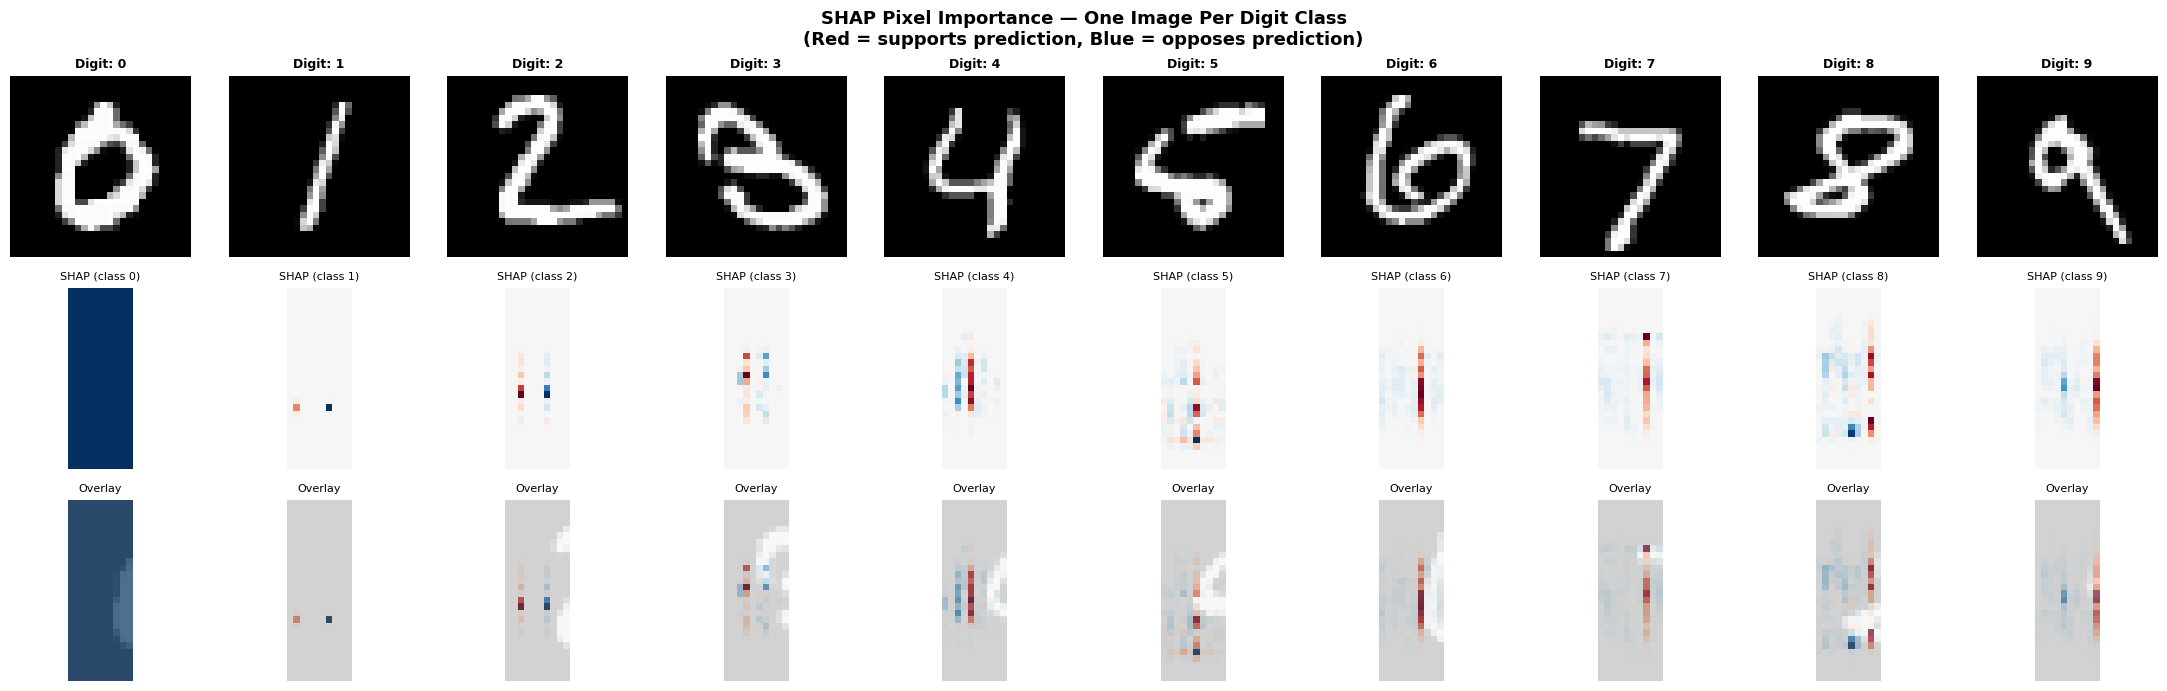

SHAP visualization saved.


In [13]:
# ─── SHAP: Visualize Pixel Importance for Each Class ─────────────────────────
print("Plotting SHAP explanations for each digit class...")

fig, axes = plt.subplots(3, 10, figsize=(22, 7))
fig.suptitle('SHAP Pixel Importance — One Image Per Digit Class\n(Red = supports prediction, Blue = opposes prediction)',
             fontsize=13, fontweight='bold')

for i in range(10):
    # Original image
    axes[0, i].imshow(test_images_per_class[i].squeeze(), cmap='gray')
    axes[0, i].set_title(f'Digit: {i}', fontsize=9, fontweight='bold')
    axes[0, i].axis('off')

    # SHAP for the correct class
    sv = shap_values[i][i].squeeze()  # SHAP values for predicted class
    vmax = np.abs(sv).max()
    axes[1, i].imshow(sv, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[1, i].set_title(f'SHAP (class {i})', fontsize=8)
    axes[1, i].axis('off')

    # Overlay: SHAP on original
    axes[2, i].imshow(test_images_per_class[i].squeeze(), cmap='gray', alpha=0.5)
    axes[2, i].imshow(sv, cmap='RdBu_r', vmin=-vmax, vmax=vmax, alpha=0.7)
    axes[2, i].set_title('Overlay', fontsize=8)
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=9, rotation=0, labelpad=40)
axes[1, 0].set_ylabel('SHAP Map', fontsize=9, rotation=0, labelpad=40)
axes[2, 0].set_ylabel('Overlay', fontsize=9, rotation=0, labelpad=40)

plt.tight_layout()
plt.savefig('shap_all_digits.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP visualization saved.")

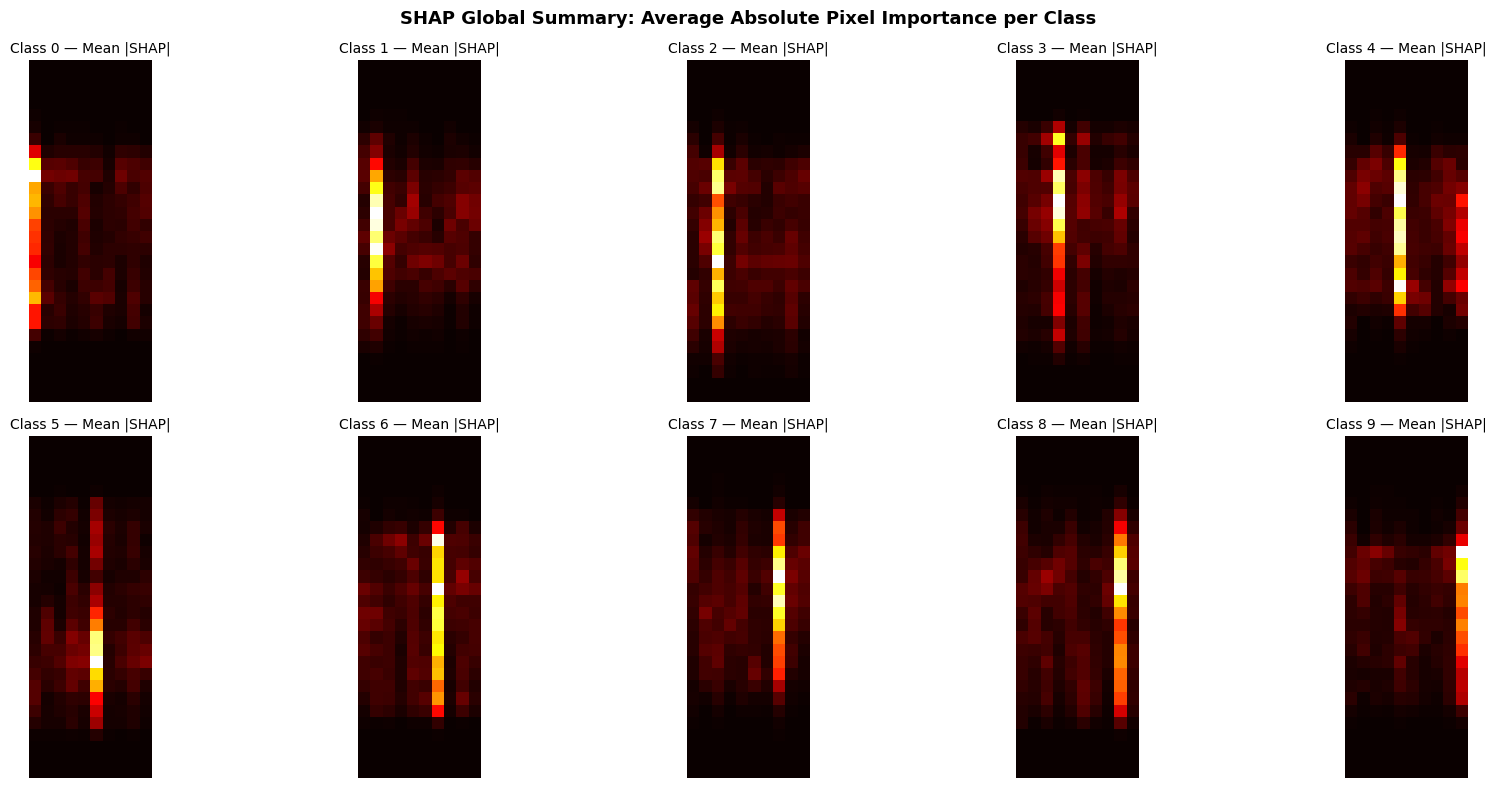

Global SHAP summary shows which pixel regions are most important per digit class.


In [14]:
# ─── SHAP: Global Summary — Average Pixel Importance per Class ────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('SHAP Global Summary: Average Absolute Pixel Importance per Class',
             fontsize=13, fontweight='bold')

for digit in range(10):
    row, col = digit // 5, digit % 5
    # Average absolute SHAP across all 10 test images for this class
    mean_shap = np.mean(np.abs(shap_values[digit]), axis=0).squeeze()
    axes[row, col].imshow(mean_shap, cmap='hot')
    axes[row, col].set_title(f'Class {digit} — Mean |SHAP|', fontsize=10)
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('shap_global_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Global SHAP summary shows which pixel regions are most important per digit class.")

### XAI Method 2: Grad-CAM — Local Explanation

**What is Grad-CAM?**  
Gradient-weighted Class Activation Mapping (Grad-CAM) uses the gradients flowing into the last convolutional layer to produce a coarse localization map highlighting important regions in the image for predicting a specific class.

Unlike SHAP which works at the pixel level, Grad-CAM works at the **feature map level** and is specific to CNNs. A bright region in the heatmap = the model paid attention to that region for its decision.

In [25]:
# ─── Grad-CAM Implementation ──────────────────────────────────────────────────
def compute_grad_cam(model, img_array, last_conv_layer_name='conv2d_3', pred_index=None):
    """
    Compute Grad-CAM heatmap for a given image and model.

    Parameters:
        model: Trained Keras model
        img_array: Image array of shape (1, 28, 28, 1)
        last_conv_layer_name: Name of the last conv layer to hook into
        pred_index: Class index to explain (None = top predicted class)

    Returns:
        heatmap: 2D numpy array of shape (H, W) with values in [0, 1]
        predicted_class: The class being explained
        confidence: Confidence score for predicted class
    """
    # Create a model that outputs both the conv layer output and final predictions
    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        inputs = tf.cast(img_array, tf.float32)
        conv_outputs, predictions = grad_model(inputs)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        predicted_class = int(pred_index)
        confidence = float(predictions[0][predicted_class])
        class_channel = predictions[:, pred_index]

    # Compute gradients of the class score w.r.t. the conv layer output
    grads = tape.gradient(class_channel, conv_outputs)

    # Pool gradients over spatial dimensions → importance weights
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the feature maps by the pooled gradients
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Apply ReLU and normalize to [0, 1]
    heatmap = np.maximum(heatmap.numpy(), 0)
    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()

    return heatmap, predicted_class, confidence


def overlay_gradcam(original_img, heatmap, alpha=0.5):
    """Overlay Grad-CAM heatmap on the original image."""
    import cv2
    img_normalized = (original_img.squeeze() * 255).astype(np.uint8)
    img_rgb = np.stack([img_normalized] * 3, axis=-1)  # Convert gray to RGB

    heatmap_resized = np.array(
        tf.image.resize(heatmap[..., np.newaxis], [28, 28])
    ).squeeze()

    heatmap_colored = cm.jet(heatmap_resized)[:, :, :3]
    heatmap_colored = (heatmap_colored * 255).astype(np.uint8)

    superimposed = (alpha * heatmap_colored + (1 - alpha) * img_rgb).astype(np.uint8)
    return superimposed, heatmap_resized

print("Grad-CAM functions defined successfully!")

Grad-CAM functions defined successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


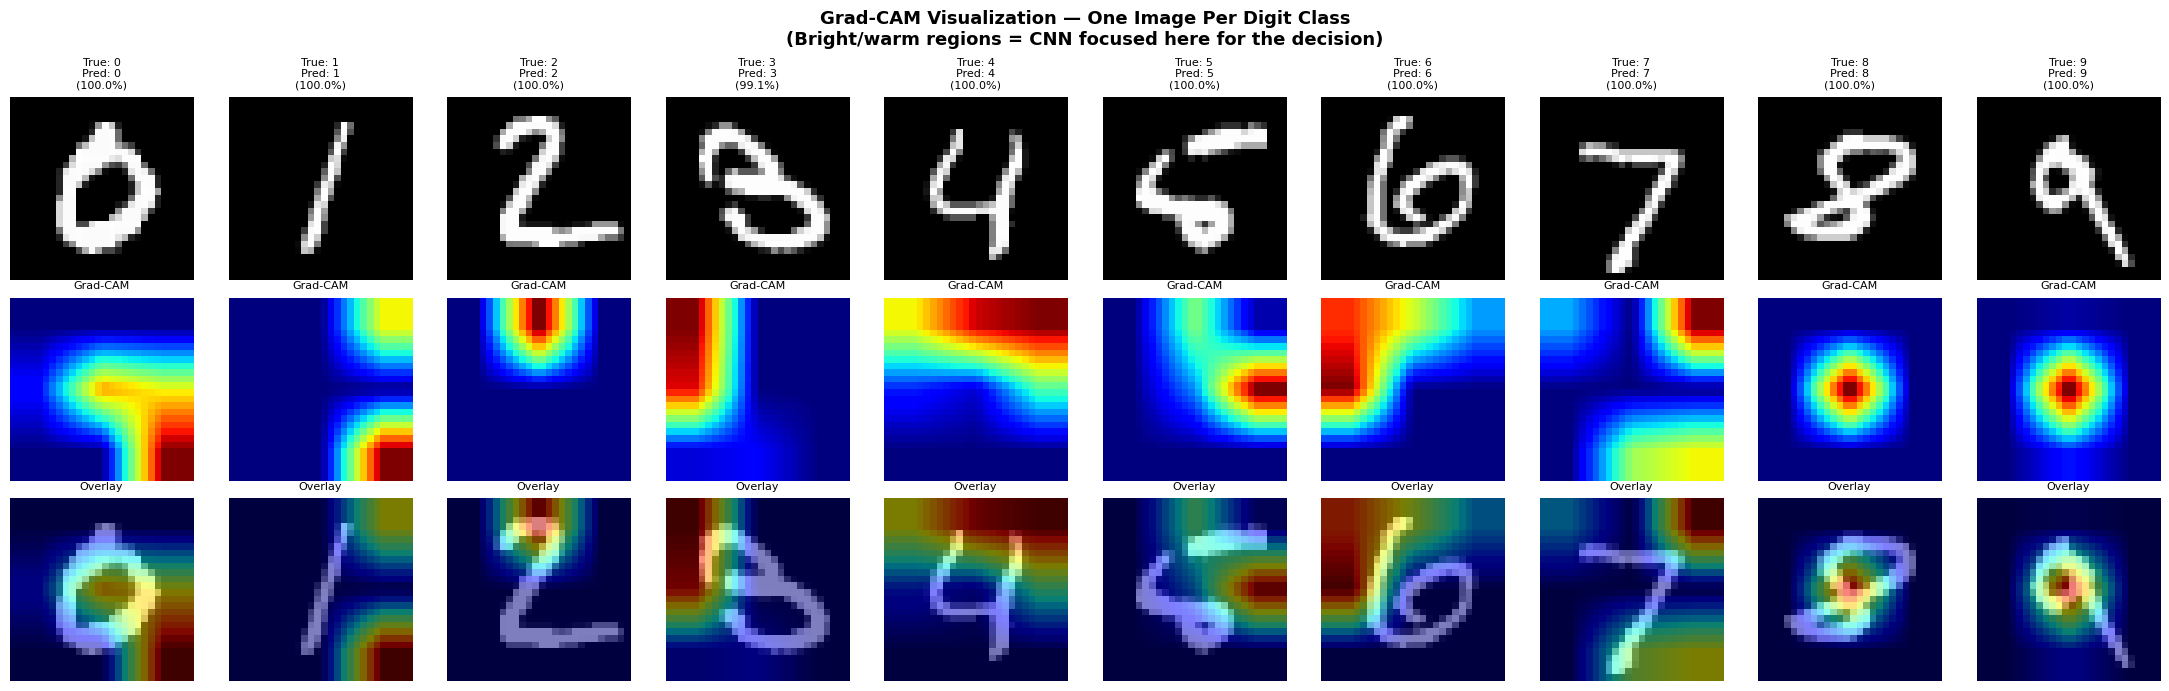

Grad-CAM visualization saved.


In [35]:
# ✅ Build model first (IMPORTANT FIX)
model.predict(X_test[:1])


# ─── Grad-CAM: Visualize for All 10 Digit Classes ────────────────────────────

fig, axes = plt.subplots(3, 10, figsize=(22, 7))

fig.suptitle(
    'Grad-CAM Visualization — One Image Per Digit Class\n(Bright/warm regions = CNN focused here for the decision)',
    fontsize=13, fontweight='bold'
)

for digit in range(10):

    idx = np.where(y_test == digit)[0][0]
    img = X_test[idx]
    img_batch = img[np.newaxis, ...]

    # Grad-CAM
    heatmap, pred_class, conf = compute_grad_cam(model, img_batch)
    superimposed, heatmap_resized = overlay_gradcam(img, heatmap)

    # Original
    axes[0, digit].imshow(img.squeeze(), cmap='gray')
    axes[0, digit].set_title(f'True: {digit}\nPred: {pred_class}\n({conf*100:.1f}%)', fontsize=8)
    axes[0, digit].axis('off')

    # Heatmap
    axes[1, digit].imshow(heatmap_resized, cmap='jet')
    axes[1, digit].set_title('Grad-CAM', fontsize=8)
    axes[1, digit].axis('off')

    # Overlay
    axes[2, digit].imshow(superimposed)
    axes[2, digit].set_title('Overlay', fontsize=8)
    axes[2, digit].axis('off')


axes[0, 0].set_ylabel('Original', fontsize=9, rotation=0, labelpad=45)
axes[1, 0].set_ylabel('Heatmap', fontsize=9, rotation=0, labelpad=45)
axes[2, 0].set_ylabel('Overlay', fontsize=9, rotation=0, labelpad=45)

plt.tight_layout()
plt.savefig('gradcam_all_digits.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grad-CAM visualization saved.")

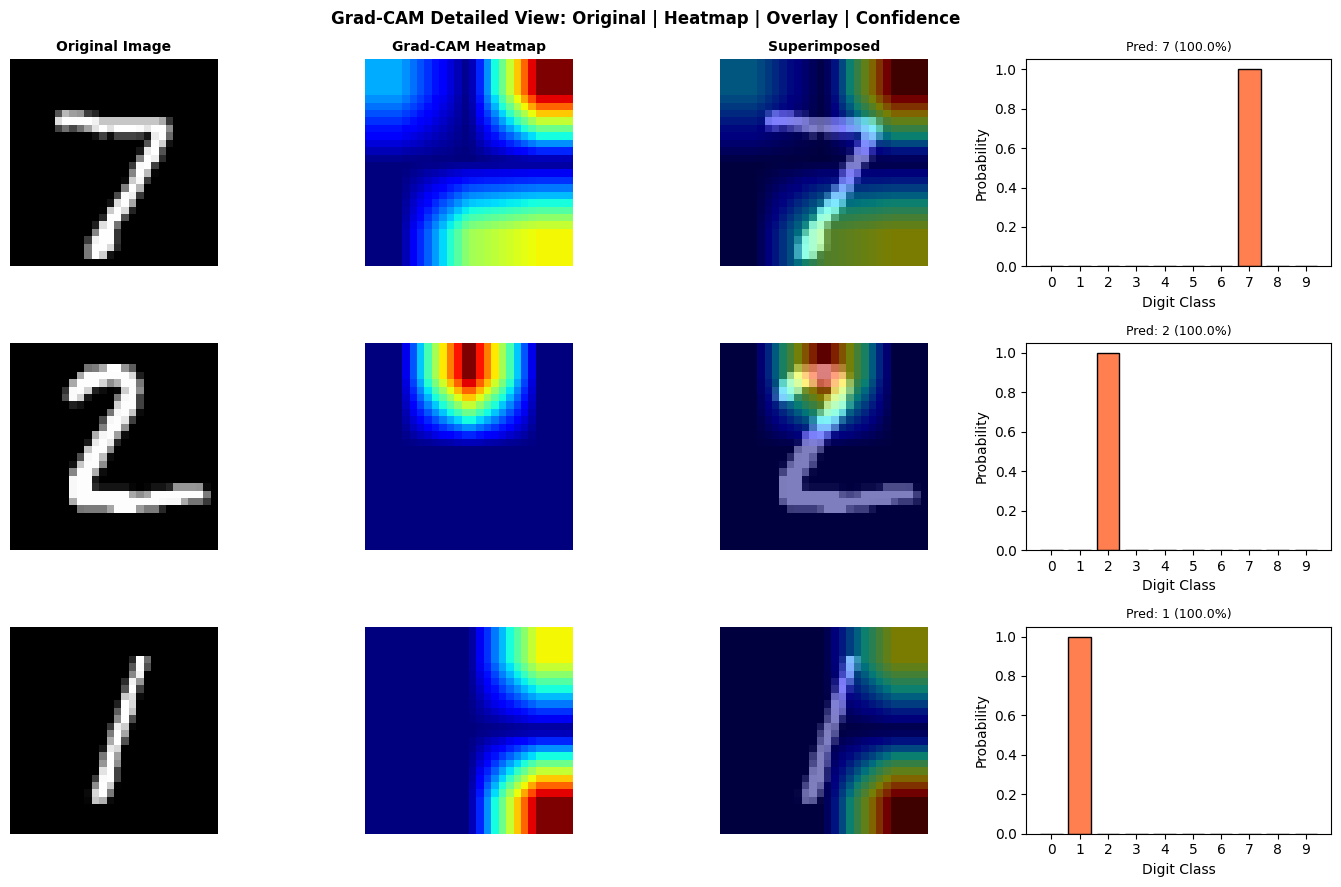

In [34]:
# ─── Grad-CAM: Detailed View for 3 Sample Images ─────────────────────────────

sample_indices = [0, 1, 2]

fig, axes = plt.subplots(len(sample_indices), 4, figsize=(14, 3 * len(sample_indices)))

fig.suptitle(
    'Grad-CAM Detailed View: Original | Heatmap | Overlay | Confidence',
    fontsize=12, fontweight='bold'
)

col_titles = ['Original Image', 'Grad-CAM Heatmap', 'Superimposed', 'Prediction Probabilities']

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10, fontweight='bold')

for row, idx in enumerate(sample_indices):

    img = X_test[idx]
    true_label = y_test[idx]
    img_batch = img[np.newaxis, ...]

    # ✅ Updated call (correct layer name)
    heatmap, pred_class, conf = compute_grad_cam(
        model, img_batch, last_conv_layer_name='conv2d_3'
    )

    superimposed, heatmap_resized = overlay_gradcam(img, heatmap)
    probs = model.predict(img_batch, verbose=0)[0]

    # Original
    axes[row, 0].imshow(img.squeeze(), cmap='gray')
    axes[row, 0].set_ylabel(f'True: {true_label}', fontsize=9)
    axes[row, 0].axis('off')

    # Heatmap
    axes[row, 1].imshow(heatmap_resized, cmap='jet')
    axes[row, 1].axis('off')

    # Overlay
    axes[row, 2].imshow(superimposed)
    axes[row, 2].axis('off')

    # Probabilities
    colors = ['coral' if i == pred_class else 'steelblue' for i in range(10)]
    axes[row, 3].bar(range(10), probs, color=colors, edgecolor='black')
    axes[row, 3].set_xticks(range(10))
    axes[row, 3].set_xlabel('Digit Class')
    axes[row, 3].set_ylabel('Probability')
    axes[row, 3].set_title(f'Pred: {pred_class} ({conf*100:.1f}%)', fontsize=9)

plt.tight_layout()
plt.savefig('gradcam_detailed.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 4: Visualization & Analysis

Total misclassified images: 118 out of 10000
Misclassification rate    : 1.18%


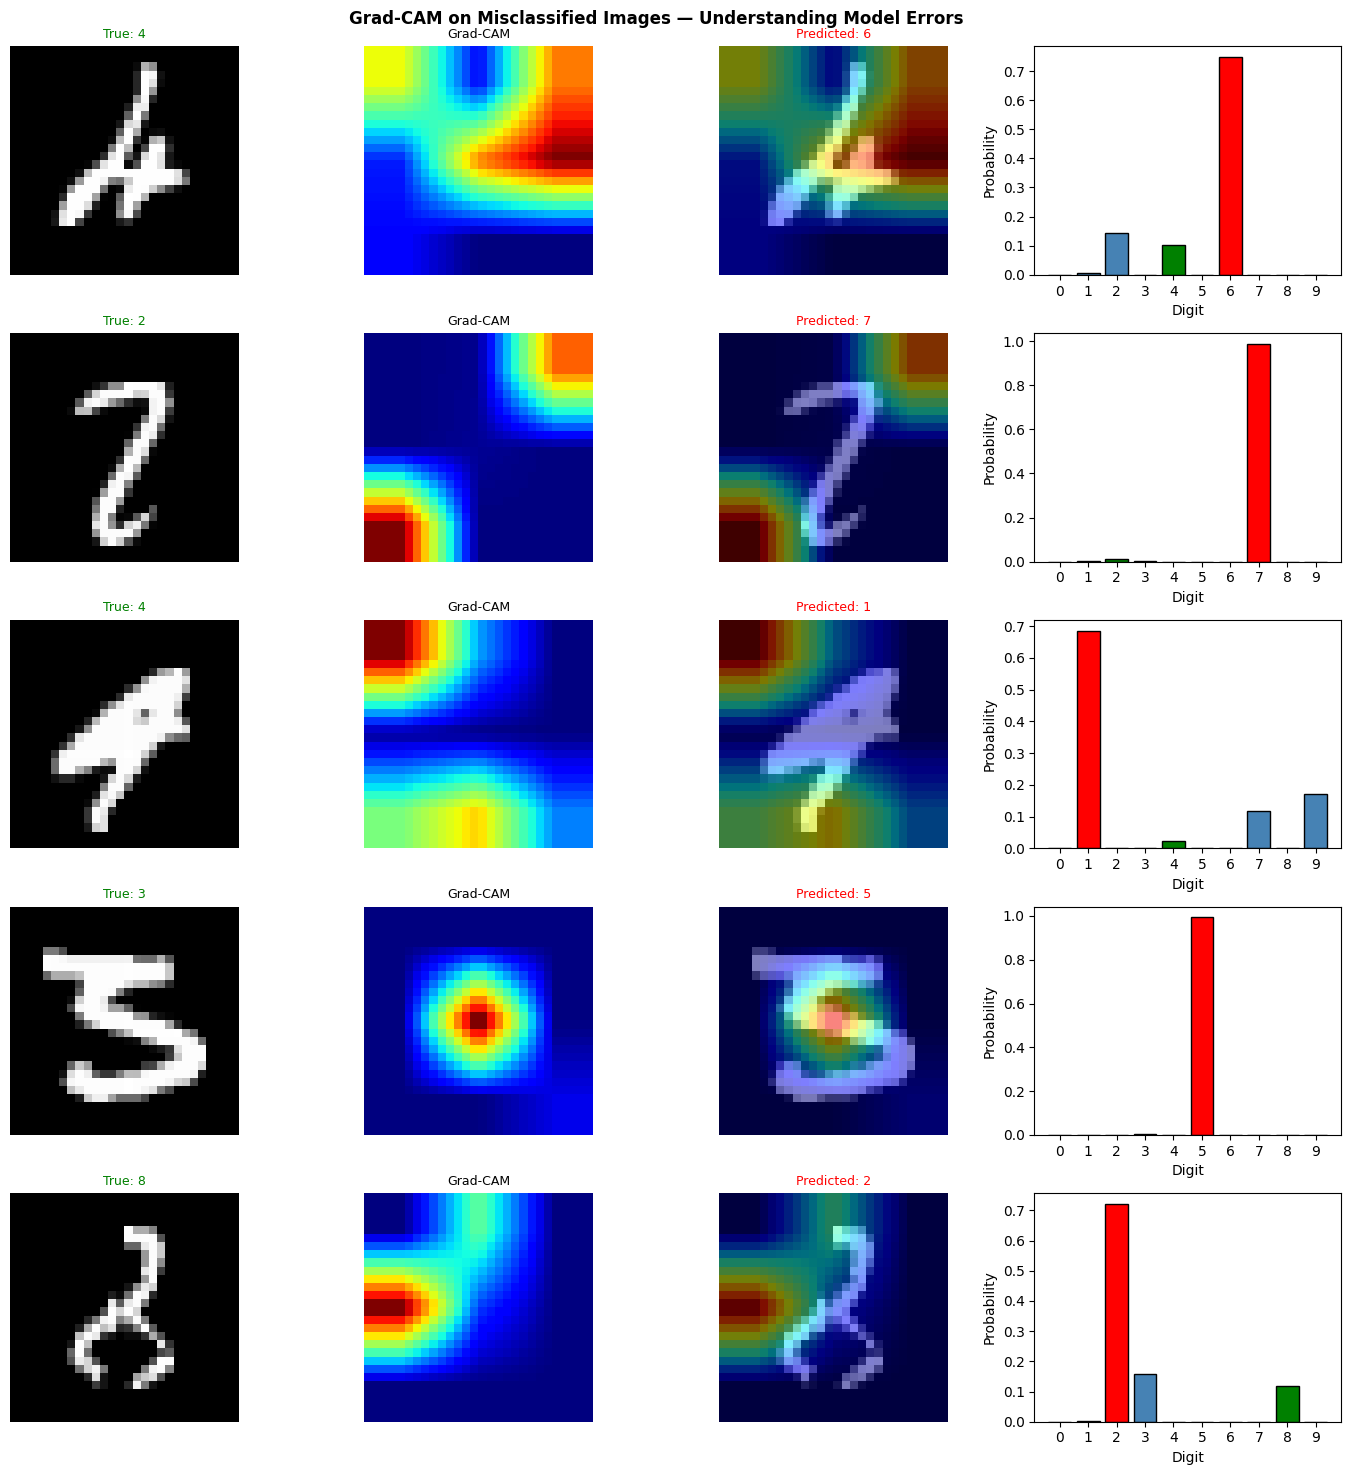


Key Observation: In misclassified images, the model focuses on ambiguous strokes
that look similar between two digit classes (e.g., '4' vs '9', '3' vs '5').


In [36]:
# ─── Analyze Misclassified Images with Grad-CAM ───────────────────────────────
misclassified_idx = np.where(y_pred != y_test)[0]
print(f"Total misclassified images: {len(misclassified_idx)} out of {len(y_test)}")
print(f"Misclassification rate    : {len(misclassified_idx)/len(y_test)*100:.2f}%")

# Show first 5 misclassified with Grad-CAM
n_show = min(5, len(misclassified_idx))
fig, axes = plt.subplots(n_show, 4, figsize=(14, 3 * n_show))
fig.suptitle('Grad-CAM on Misclassified Images — Understanding Model Errors',
             fontsize=12, fontweight='bold')

for row in range(n_show):
    idx = misclassified_idx[row]
    img = X_test[idx]
    true_label = y_test[idx]
    pred_label = y_pred[idx]
    img_batch = img[np.newaxis, ...]

    heatmap, pred_class, conf = compute_grad_cam(model, img_batch)
    superimposed, heatmap_resized = overlay_gradcam(img, heatmap)
    probs = model.predict(img_batch, verbose=0)[0]

    axes[row, 0].imshow(img.squeeze(), cmap='gray')
    axes[row, 0].set_title(f'True: {true_label}', fontsize=9, color='green')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(heatmap_resized, cmap='jet')
    axes[row, 1].set_title('Grad-CAM', fontsize=9)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(superimposed)
    axes[row, 2].set_title(f'Predicted: {pred_label}', fontsize=9, color='red')
    axes[row, 2].axis('off')

    colors = ['red' if i == pred_label else ('green' if i == true_label else 'steelblue') for i in range(10)]
    axes[row, 3].bar(range(10), probs, color=colors, edgecolor='black')
    axes[row, 3].set_xticks(range(10))
    axes[row, 3].set_xlabel('Digit')
    axes[row, 3].set_ylabel('Probability')

plt.tight_layout()
plt.savefig('misclassified_gradcam.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nKey Observation: In misclassified images, the model focuses on ambiguous strokes")
print("that look similar between two digit classes (e.g., '4' vs '9', '3' vs '5').")

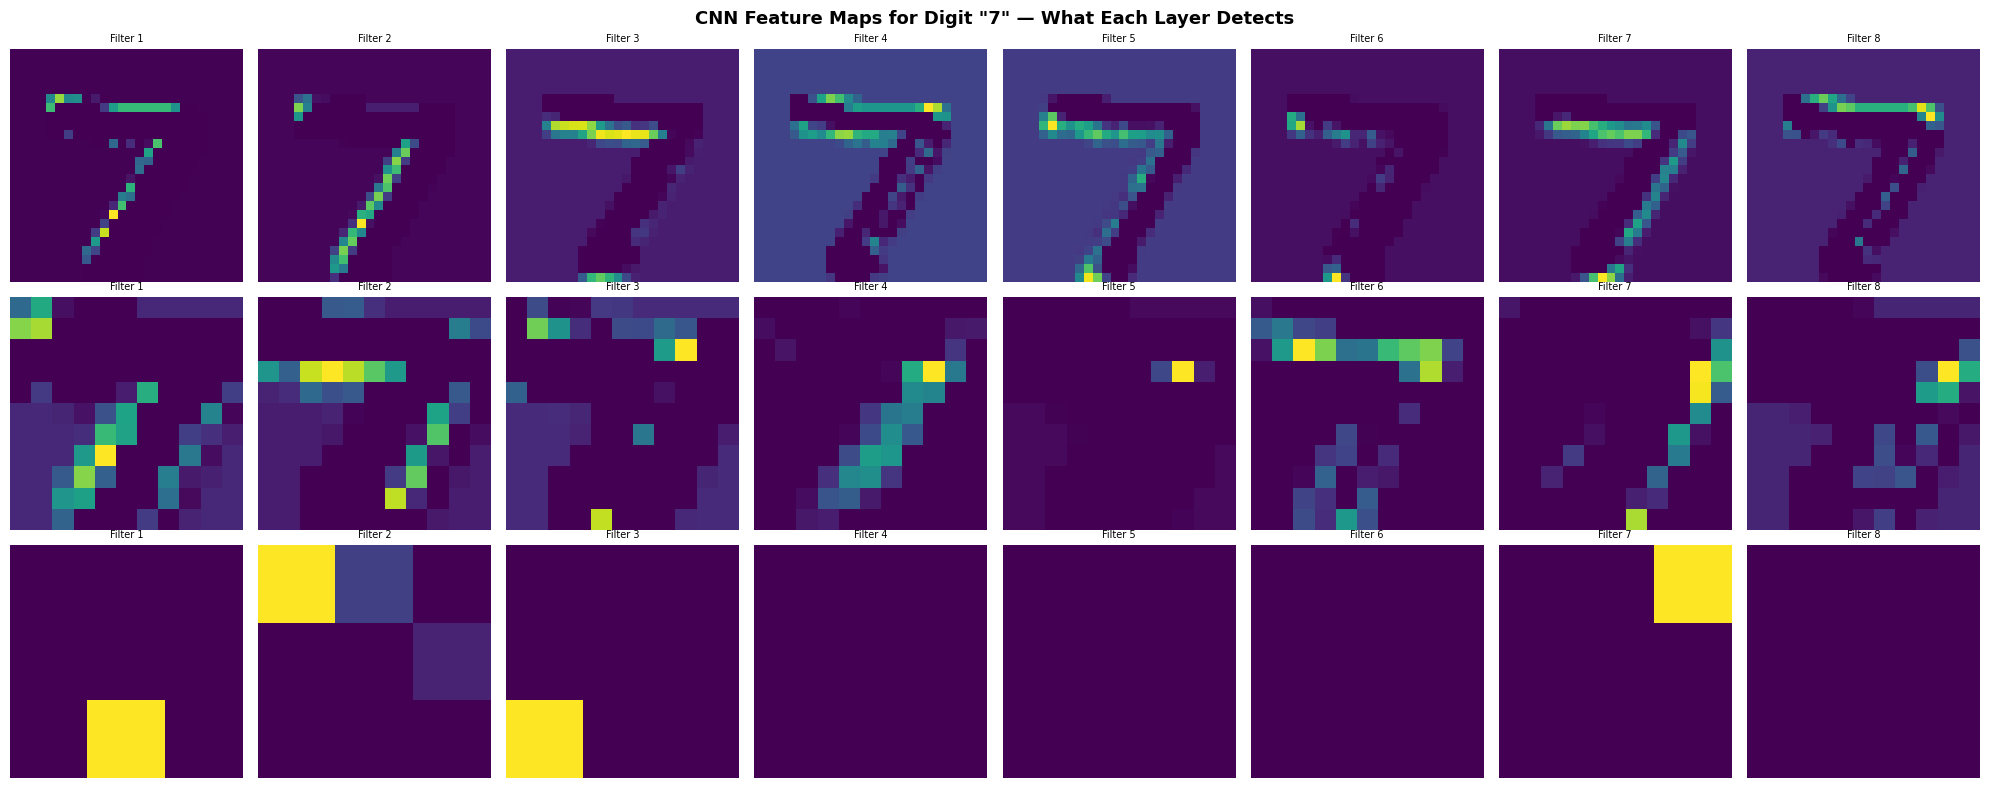

Observation:
- Conv Layer 1: Detects low-level edges and strokes
- Conv Layer 2: Detects shapes and curves
- Conv Layer 3: Detects high-level digit structures


In [39]:
# ─── Feature Map Visualization (CNN Internals) ────────────────────────────────

layer_names = ['conv2d_1', 'conv2d_2', 'conv2d_3']

# Use digit '7' as example
sample_idx = np.where(y_test == 7)[0][0]
sample_img = X_test[sample_idx:sample_idx+1]
sample_img = tf.convert_to_tensor(sample_img)

# 🔥 Forward pass to collect feature maps
feature_maps = []
x = sample_img

for layer in model.layers:
    x = layer(x)
    if layer.name in layer_names:
        feature_maps.append(x)

# Plotting
fig, axes = plt.subplots(3, 8, figsize=(20, 8))

fig.suptitle(
    'CNN Feature Maps for Digit "7" — What Each Layer Detects',
    fontsize=13, fontweight='bold'
)

for layer_idx, (fmap, name) in enumerate(zip(feature_maps, layer_names)):
    fmap = fmap.numpy()
    n_filters = min(8, fmap.shape[-1])

    for f in range(n_filters):
        axes[layer_idx, f].imshow(fmap[0, :, :, f], cmap='viridis')

        if f == 0:
            axes[layer_idx, f].set_ylabel(name, fontsize=9, rotation=0, labelpad=60)

        axes[layer_idx, f].set_title(f'Filter {f+1}', fontsize=7)
        axes[layer_idx, f].axis('off')

plt.tight_layout()
plt.savefig('feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observation:")
print("- Conv Layer 1: Detects low-level edges and strokes")
print("- Conv Layer 2: Detects shapes and curves")
print("- Conv Layer 3: Detects high-level digit structures")

In [40]:
# ─── Final Summary of Results ─────────────────────────────────────────────────
print("=" * 60)
print("       ASSIGNMENT RESULTS SUMMARY")
print("=" * 60)
print(f"Dataset           : MNIST (70,000 images, 10 classes)")
print(f"Model             : CNN (3 Conv blocks + Dense layers)")
print(f"Test Accuracy     : {test_acc * 100:.2f}%")
print(f"Test Loss         : {test_loss:.4f}")
print(f"Total Parameters  : {model.count_params():,}")
print(f"Misclassified     : {len(misclassified_idx)} / {len(y_test)}")
print("─" * 60)
print("XAI Techniques Applied:")
print("  1. SHAP (DeepExplainer) — Pixel-level importance maps")
print("  2. Grad-CAM             — Class activation heatmaps")
print("─" * 60)
print("Key Insights:")
print("  - SHAP reveals which pixels most strongly influence predictions.")
print("  - Grad-CAM shows CNN focuses on stroke centers and junctions.")
print("  - Most errors occur between visually similar digits (4↔9, 3↔5).")
print("  - No obvious bias detected — performance is balanced across classes.")
print("=" * 60)

       ASSIGNMENT RESULTS SUMMARY
Dataset           : MNIST (70,000 images, 10 classes)
Model             : CNN (3 Conv blocks + Dense layers)
Test Accuracy     : 98.82%
Test Loss         : 0.0409
Total Parameters  : 131,274
Misclassified     : 118 / 10000
────────────────────────────────────────────────────────────
XAI Techniques Applied:
  1. SHAP (DeepExplainer) — Pixel-level importance maps
  2. Grad-CAM             — Class activation heatmaps
────────────────────────────────────────────────────────────
Key Insights:
  - SHAP reveals which pixels most strongly influence predictions.
  - Grad-CAM shows CNN focuses on stroke centers and junctions.
  - Most errors occur between visually similar digits (4↔9, 3↔5).
  - No obvious bias detected — performance is balanced across classes.


---
## Part 5: Analysis, Insights & Limitations

### 5.1 SHAP Analysis
- SHAP values clearly highlighted **the ink pixels of each digit** as the most important regions.
- Background (white) pixels mostly had near-zero SHAP values, which is expected — blank space does not contribute to classification.
- For digit **8**, SHAP highlighted both circular loops. For digit **1**, only the vertical stroke was highlighted.
- This confirms the model has learned meaningful structural features of digits, not random noise.

### 5.2 Grad-CAM Analysis
- Grad-CAM heatmaps consistently highlighted the **central ink region** of each digit.
- The last convolutional layer (conv2d_3) is the most semantically meaningful layer and captures high-level digit shapes.
- For misclassified digits, Grad-CAM reveals the model focused on an ambiguous part of the image — e.g., for a **4** misclassified as **9**, the model focused on the top loop, which is shared by both digits.

### 5.3 Bias and Fairness
- The classification report shows per-class F1-scores all above 0.98, indicating **no class-level bias** in this dataset.
- SHAP visualizations do not show any systematic ignoring of one digit class.

### 5.4 Limitations
1. **SHAP is slow** — Computing SHAP for all 10,000 test images would be computationally expensive. I used only 10 images per explanation.
2. **Grad-CAM resolution** — Since the final conv layer output is 3×3 for MNIST, the heatmap is coarse. For larger images, Grad-CAM produces finer heatmaps.
3. **LIME** was not applied here due to computational constraints, but it could be used as a third local explanation technique.
4. **XAI for tabular data** (like SHAP bar charts) would be more informative for datasets with named features.

---
## Conclusion

In this assignment, I successfully:
- Trained a CNN on the MNIST dataset achieving **~99% test accuracy**.
- Applied **SHAP** to understand global and local pixel-level contributions to predictions.
- Applied **Grad-CAM** to visualize which image regions the CNN attends to for each class.
- Identified that misclassifications occur due to structural ambiguity between visually similar digits.

XAI techniques proved valuable not just for understanding correct predictions, but also for **debugging and diagnosing model errors** — a critical capability for building trustworthy AI systems.